In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 删除无意义的列
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

# 将目标变量转为数值
df['Attrition_num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 数值型字段与离职的相关性
num_cols = df.select_dtypes(include='int64').columns.tolist()
corr_with_attrition = df[num_cols + ['Attrition_num']].corr()['Attrition_num'].drop('Attrition_num').sort_values()

# 可视化
fig, ax = plt.subplots(figsize=(10, 12))
corr_with_attrition.plot(kind='barh', ax=ax, color=corr_with_attrition.apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
ax.set_title('各数值特征与离职的相关系数', fontsize=16)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n=== 正相关 TOP5（越高越容易离职）===")
print(corr_with_attrition.tail(5))
print("\n=== 负相关 TOP5（越高越不容易离职）===")
print(corr_with_attrition.head(5))

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

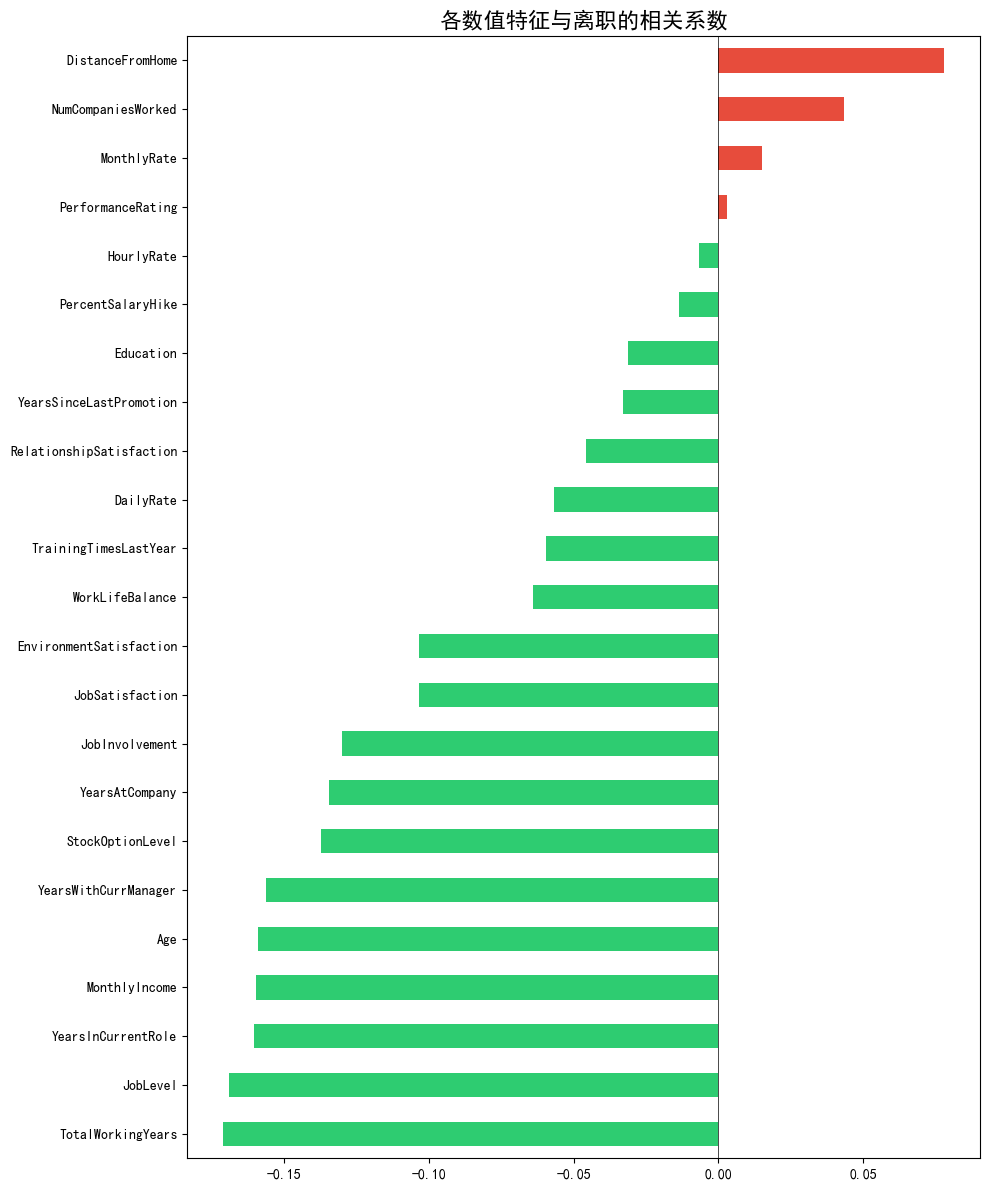


=== 正相关 TOP5（越高越容易离职）===
HourlyRate           -0.006846
PerformanceRating     0.002889
MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
dtype: float64

=== 负相关 TOP5（越高越不容易离职）===
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205
dtype: float64


In [4]:
corr_series = df[num_cols + ['Attrition_num']].corrwith(df['Attrition_num']).drop('Attrition_num').sort_values()

# 可视化
fig, ax = plt.subplots(figsize=(10, 12))
corr_series.plot(kind='barh', ax=ax, color=corr_series.apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
ax.set_title('各数值特征与离职的相关系数', fontsize=16)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n=== 正相关 TOP5（越高越容易离职）===")
print(corr_series.tail(5))
print("\n=== 负相关 TOP5（越高越不容易离职）===")
print(corr_series.head(5))

In [5]:
# 分类变量编码
df_model = df.copy()

# 二值变量直接映射
df_model['OverTime'] = df_model['OverTime'].map({'Yes': 1, 'No': 0})
df_model['Gender'] = df_model['Gender'].map({'Male': 1, 'Female': 0})

# 多类别变量用 One-Hot 编码
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# 删除原始目标变量（保留数值版）
df_model = df_model.drop(columns=['Attrition'])

print(f"编码后数据集形状: {df_model.shape}")
print(f"\n前5列样例:")
df_model.head()

编码后数据集形状: (1470, 45)

前5列样例:


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1102,1,2,2,0,94,3,2,4,...,False,False,False,False,False,False,True,False,False,True
1,49,279,8,1,3,1,61,2,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1373,2,2,4,1,92,2,1,3,...,False,True,False,False,False,False,False,False,False,True
3,33,1392,3,4,4,0,56,3,1,3,...,False,False,False,False,False,True,False,False,True,False
4,27,591,2,1,1,1,40,3,1,2,...,False,True,False,False,False,False,False,False,True,False


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 准备特征和目标
X = df_model.drop(columns=['Attrition_num'])
y = df_model['Attrition_num']

# 划分训练集和测试集（80/20）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集: {X_train.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")
print(f"训练集离职率: {y_train.mean():.1%}")
print(f"测试集离职率: {y_test.mean():.1%}")

训练集: 1176 条
测试集: 294 条
训练集离职率: 16.2%
测试集离职率: 16.0%


In [7]:
# 模型1: 逻辑回归
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("【逻辑回归】")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['留存', '离职']))
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# 模型2: 随机森林
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 50)
print("【随机森林】")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['留存', '离职']))
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

【逻辑回归】
              precision    recall  f1-score   support

          留存       0.88      0.96      0.92       247
          离职       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

AUC: 0.808

【随机森林】
              precision    recall  f1-score   support

          留存       0.85      0.98      0.91       247
          离职       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294

AUC: 0.745


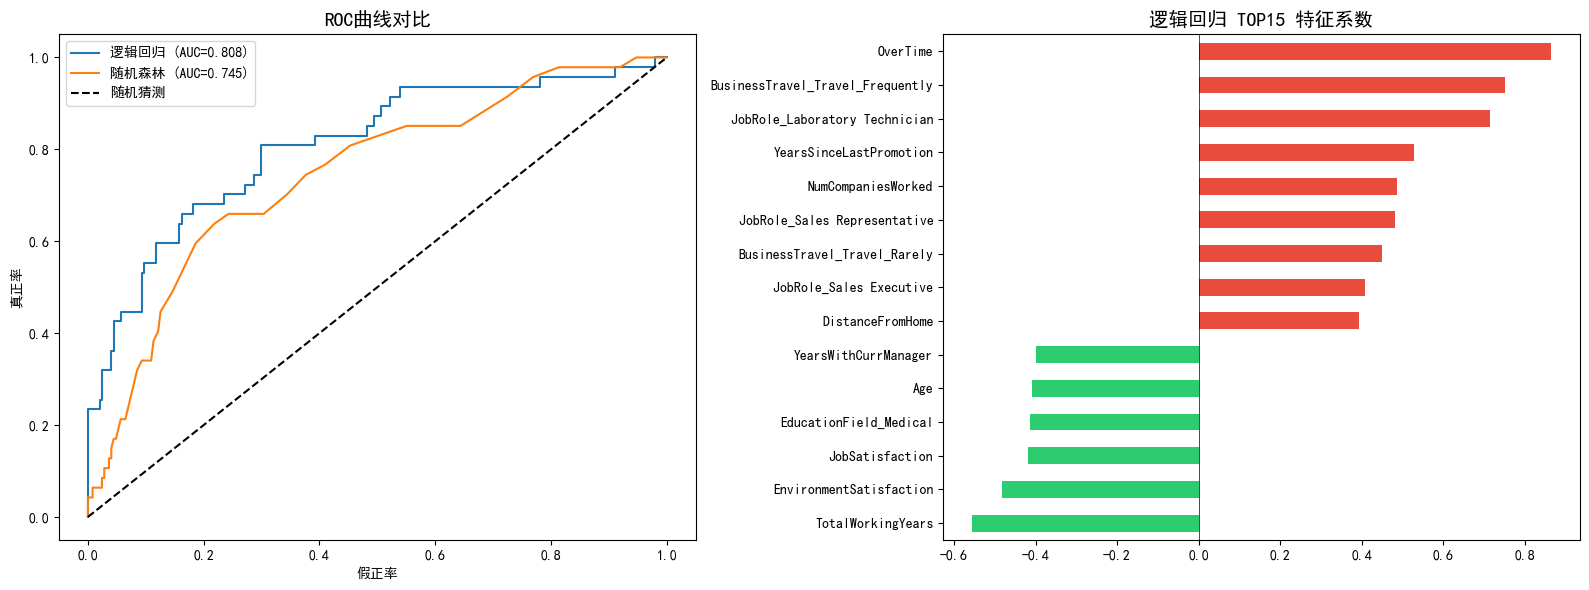

In [8]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC曲线对比
for name, y_prob in [('逻辑回归', y_prob_lr), ('随机森林', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', label='随机猜测')
axes[0].set_title('ROC曲线对比', fontsize=14)
axes[0].set_xlabel('假正率')
axes[0].set_ylabel('真正率')
axes[0].legend()

# 逻辑回归特征重要性（系数绝对值TOP15）
coef = pd.Series(lr.coef_[0], index=X.columns)
top15 = coef.abs().sort_values(ascending=False).head(15).index
coef[top15].sort_values().plot(kind='barh', ax=axes[1], 
    color=coef[top15].sort_values().apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
axes[1].set_title('逻辑回归 TOP15 特征系数', fontsize=14)
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()